# Experiment: 3T PDF Comparison for Patient 001_20240313

## Objective
- Compare the full-volume probability density function (PDF) of the 3T magnitude image across three pipeline stages:
  1. Original NIfTI image
  2. Cropped temporally registered image from `data/temporal_registered_cow_crop`
  3. Exported paired dataset image from `data/paired_dataset/lr_3t`
- For the cropped and `lr_3t` images, compare the full-volume PDF, the PDF inside the CoW mask, and the PDF outside the CoW mask.

## Success Criteria
- All inputs are loaded from reproducible repo paths.
- The CoW mask is resampled to each reference image when needed.
- The notebook produces comparable PDF plots and summary statistics in English.

## Note
- The repository does not contain a folder literally named `nifit_images`.
- The defaults below therefore interpret the original image as the raw 3T NIfTI under `data/nifti_patients`, with fallback to `data/processed_inputs` if needed.


In [24]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import nibabel as nib
import nibabel.processing as nibproc
import numpy as np
import pandas as pd
from IPython.display import display

PATIENT_ID = '001_20240313'

# Set this explicitly if you want to force a single original image.
ORIGINAL_IMAGE_PATH = None
ORIGINAL_IMAGE_CANDIDATES = [
    Path(f'data/nifti_patients/{PATIENT_ID}_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz'),
    Path(f'data/nifti_patients/{PATIENT_ID}_3T/Magnitude_MSUM_NoProto_WIP_pc3d1r3.nii.gz'),
    Path(f'data/processed_inputs/{PATIENT_ID}_3T/input_mag_raw.nii.gz'),
]

CROPPED_IMAGE_PATH = Path(f'data/temporal_registered_cow_crop/{PATIENT_ID}_3T/input_mag_raw.nii.gz')
LR3T_IMAGE_PATH = Path(f'data/paired_dataset/lr_3t/{PATIENT_ID}/input_mag_raw.nii.gz')
MASK_PATH = Path(f'data/paired_dataset/cow_segmentation/{PATIENT_ID}/cow_seg_final.nii.gz')

MASK_THRESHOLD = 0.5
TIME_MODE = 'all'      # 'all' or 'frame'
FRAME_INDEX = 0        # used only when TIME_MODE == 'frame'
EXCLUDE_ZERO_VALUES = True
ZERO_EPS = 1e-8
HIST_BINS = 200
PLOT_CLIP_PERCENTILES = (0.0, 99.0)  # set to None to disable clipping
EXPORT_SUMMARY_CSV = False
EXPORT_DIR = Path('output/notebook_exports')

DATASET_STYLES = {
    'Original 3T NIfTI': {'color': '#1f77b4'},
    'Temporally registered CoW crop': {'color': '#d62728'},
    'Paired dataset lr_3t': {'color': '#2ca02c'},
}


In [25]:
def resolve_existing(path: Path) -> Path:
    path = Path(path)
    if path.exists():
        return path
    if not path.is_absolute():
        alt = Path('..') / path
        if alt.exists():
            return alt
    return path


def first_existing(paths: list[Path]) -> Path:
    for path in paths:
        resolved = resolve_existing(path)
        if resolved.exists():
            return resolved
    raise FileNotFoundError('None of the candidate paths exist:\n' + '\n'.join(str(p) for p in paths))


def load_nifti_float(path: Path) -> tuple[nib.Nifti1Image, np.ndarray, Path]:
    resolved = resolve_existing(path)
    if not resolved.exists():
        raise FileNotFoundError(f'Missing file: {path} (resolved: {resolved})')
    img = nib.load(str(resolved))
    data = np.asarray(img.dataobj, dtype=np.float32)
    return img, data, resolved


def select_mask_3d(mask_data: np.ndarray, time_index: int = 0) -> np.ndarray:
    if mask_data.ndim == 3:
        return np.asarray(mask_data, dtype=np.float32)
    if mask_data.ndim == 4:
        if not (0 <= time_index < mask_data.shape[-1]):
            raise ValueError(f'time_index={time_index} is out of range for mask shape={mask_data.shape}')
        return np.asarray(mask_data[..., time_index], dtype=np.float32)
    raise ValueError(f'Invalid mask shape={mask_data.shape}. Expected 3D or 4D.')


def align_mask_to_reference(mask_img: nib.Nifti1Image, mask_3d: np.ndarray, ref_img: nib.Nifti1Image) -> np.ndarray:
    mask_img_3d = nib.Nifti1Image(mask_3d, mask_img.affine, mask_img.header)
    same_shape = tuple(mask_img_3d.shape[:3]) == tuple(ref_img.shape[:3])
    same_affine = np.allclose(mask_img_3d.affine, ref_img.affine, atol=1e-4)
    if not (same_shape and same_affine):
        mask_img_3d = nibproc.resample_from_to(mask_img_3d, (ref_img.shape[:3], ref_img.affine), order=0)
    return np.asarray(mask_img_3d.dataobj, dtype=np.float32)


def to_binary_mask(mask_3d: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    return (np.asarray(mask_3d, dtype=np.float32) > threshold).astype(np.uint8)


def representative_volume(image_data: np.ndarray, frame_index: int = 0) -> np.ndarray:
    if image_data.ndim == 3:
        return image_data
    if image_data.ndim == 4:
        if TIME_MODE == 'frame':
            if not (0 <= frame_index < image_data.shape[-1]):
                raise ValueError(f'frame_index={frame_index} is out of range for image shape={image_data.shape}')
            return np.asarray(image_data[..., frame_index], dtype=np.float32)
        return np.asarray(np.mean(image_data, axis=-1), dtype=np.float32)
    raise ValueError(f'Invalid image shape={image_data.shape}. Expected 3D or 4D.')


def extract_region_values(
    image_data: np.ndarray,
    mask_3d: np.ndarray | None = None,
    region: str = 'full',
    time_mode: str = 'all',
    frame_index: int = 0,
) -> np.ndarray:
    if region not in {'full', 'inside_mask', 'outside_mask'}:
        raise ValueError(f'Unsupported region={region}')

    if region == 'full':
        if image_data.ndim == 3:
            return np.asarray(image_data, dtype=np.float32).ravel()
        if image_data.ndim == 4:
            if time_mode == 'frame':
                return np.asarray(image_data[..., frame_index], dtype=np.float32).ravel()
            if time_mode == 'all':
                return np.asarray(image_data, dtype=np.float32).ravel()
        raise ValueError(f'Invalid image shape={image_data.shape}')

    if mask_3d is None:
        raise ValueError('mask_3d is required for inside_mask/outside_mask regions')

    mask_bool = np.asarray(mask_3d > 0, dtype=bool)
    if region == 'outside_mask':
        mask_bool = ~mask_bool

    if image_data.ndim == 3:
        return np.asarray(image_data[mask_bool], dtype=np.float32)

    if image_data.ndim == 4:
        if time_mode == 'frame':
            return np.asarray(image_data[..., frame_index][mask_bool], dtype=np.float32)
        if time_mode == 'all':
            return np.asarray(image_data[mask_bool, :], dtype=np.float32).ravel()

    raise ValueError(f'Invalid image shape={image_data.shape}')


def clean_values(values: np.ndarray, exclude_zeros: bool = True, zero_eps: float = 1e-8) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float32).ravel()
    arr = arr[np.isfinite(arr)]
    if exclude_zeros:
        arr = arr[np.abs(arr) > zero_eps]
    return arr


def clip_values(values: np.ndarray, clip_percentiles: tuple[float, float] | None) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float32)
    if arr.size == 0 or clip_percentiles is None:
        return arr
    low, high = np.percentile(arr, clip_percentiles)
    if not np.isfinite(low) or not np.isfinite(high):
        return arr
    if low == high:
        return arr
    return np.clip(arr, low, high)


def summarize_values(values: np.ndarray) -> dict[str, float]:
    arr = np.asarray(values, dtype=np.float32)
    if arr.size == 0:
        return {
            'n': 0,
            'mean': np.nan,
            'std': np.nan,
            'median': np.nan,
            'p01': np.nan,
            'p05': np.nan,
            'p95': np.nan,
            'p99': np.nan,
            'min': np.nan,
            'max': np.nan,
        }
    return {
        'n': int(arr.size),
        'mean': float(np.mean(arr)),
        'std': float(np.std(arr)),
        'median': float(np.median(arr)),
        'p01': float(np.percentile(arr, 1)),
        'p05': float(np.percentile(arr, 5)),
        'p95': float(np.percentile(arr, 95)),
        'p99': float(np.percentile(arr, 99)),
        'min': float(np.min(arr)),
        'max': float(np.max(arr)),
    }


def compute_pdf(values: np.ndarray, bins: int, value_range: tuple[float, float]) -> dict[str, np.ndarray]:
    lo, hi = value_range
    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError(f'Invalid histogram range: {(lo, hi)}')
    if lo == hi:
        hi = lo + 1e-6
    counts, edges = np.histogram(values, bins=bins, range=(lo, hi))
    widths = np.diff(edges)
    centers = edges[:-1] + widths / 2.0
    total = counts.sum()
    if total == 0:
        pdf = np.zeros_like(centers, dtype=np.float32)
    else:
        pdf = counts.astype(np.float64) / total / widths
    return {
        'counts': counts,
        'edges': edges,
        'centers': centers,
        'pdf': pdf,
    }


def prepare_overlay(series_map: dict[str, np.ndarray], bins: int, clip_percentiles: tuple[float, float] | None) -> dict[str, dict[str, np.ndarray]]:
    cleaned = {label: clean_values(values, exclude_zeros=EXCLUDE_ZERO_VALUES, zero_eps=ZERO_EPS) for label, values in series_map.items()}
    non_empty = {label: values for label, values in cleaned.items() if values.size > 0}
    if not non_empty:
        raise ValueError('No valid values available for PDF computation.')

    combined = np.concatenate(list(non_empty.values()))
    if clip_percentiles is not None:
        lo, hi = np.percentile(combined, clip_percentiles)
    else:
        lo, hi = float(np.min(combined)), float(np.max(combined))
    if lo == hi:
        hi = lo + 1e-6

    prepared = {}
    for label, values in non_empty.items():
        clipped = np.clip(values, lo, hi) if clip_percentiles is not None else values
        prepared[label] = {
            'raw': values,
            'plot': clipped,
            **compute_pdf(clipped, bins=bins, value_range=(float(lo), float(hi))),
        }
    return prepared


def build_summary_table(rows: list[dict[str, object]]) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    numeric_cols = ['n', 'mean', 'std', 'median', 'p01', 'p05', 'p95', 'p99', 'min', 'max']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def choose_mask_slice(mask_3d: np.ndarray) -> int:
    sums = np.sum(mask_3d > 0, axis=(0, 1))
    if np.max(sums) <= 0:
        return mask_3d.shape[2] // 2
    return int(np.argmax(sums))


def show_mask_overlay(ax, volume_3d: np.ndarray, mask_3d: np.ndarray, title: str, cmap: str = 'gray') -> None:
    z_index = choose_mask_slice(mask_3d)
    image_slice = np.asarray(volume_3d[:, :, z_index], dtype=np.float32)
    mask_slice = np.asarray(mask_3d[:, :, z_index], dtype=bool)

    vmin, vmax = np.percentile(image_slice[np.isfinite(image_slice)], [1, 99])
    ax.imshow(np.rot90(image_slice), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.contour(np.rot90(mask_slice.astype(np.uint8)), levels=[0.5], colors=['#ffdd57'], linewidths=1.5)
    ax.set_title(f'{title}\nSlice z={z_index}')
    ax.axis('off')


In [26]:
original_path = resolve_existing(Path(ORIGINAL_IMAGE_PATH)) if ORIGINAL_IMAGE_PATH is not None else first_existing(ORIGINAL_IMAGE_CANDIDATES)

dataset_specs = {
    'Original 3T NIfTI': {
        'path': original_path,
        'mask_analysis': False,
    },
    'Temporally registered CoW crop': {
        'path': CROPPED_IMAGE_PATH,
        'mask_analysis': True,
    },
    'Paired dataset lr_3t': {
        'path': LR3T_IMAGE_PATH,
        'mask_analysis': True,
    },
}

mask_img, mask_data_raw, resolved_mask_path = load_nifti_float(MASK_PATH)
mask_3d_native = select_mask_3d(mask_data_raw, time_index=0)

loaded = {}
for label, spec in dataset_specs.items():
    img, data, resolved_path = load_nifti_float(spec['path'])
    entry = {
        'label': label,
        'path': resolved_path,
        'img': img,
        'data': data,
        'style': DATASET_STYLES[label],
    }
    if spec['mask_analysis']:
        aligned_mask = align_mask_to_reference(mask_img, mask_3d_native, img)
        binary_mask = to_binary_mask(aligned_mask, threshold=MASK_THRESHOLD)
        entry['mask'] = binary_mask
        entry['mask_voxels'] = int(binary_mask.sum())
    loaded[label] = entry

print('Resolved original image:', original_path)
print('Resolved mask:', resolved_mask_path)
print('Time mode:', TIME_MODE)
print('Frame index:', FRAME_INDEX)
print('Exclude zeros:', EXCLUDE_ZERO_VALUES)


Resolved original image: ../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz
Resolved mask: ../data/paired_dataset/cow_segmentation/001_20240313/cow_seg_final.nii.gz
Time mode: all
Frame index: 0
Exclude zeros: True


In [27]:
metadata_rows = []
for label, entry in loaded.items():
    img = entry['img']
    metadata_rows.append({
        'dataset': label,
        'path': str(entry['path']),
        'shape': tuple(img.shape),
        'dtype': str(img.get_data_dtype()),
        'zooms': tuple(np.round(img.header.get_zooms(), 4)),
        'mask_voxels': entry.get('mask_voxels', np.nan),
    })

metadata_df = pd.DataFrame(metadata_rows)
display(metadata_df)


,dataset,path,shape,dtype,zooms,mask_voxels
0,Original 3T NIfTI,../data/nifti_patients/001_20240313_3T/Magnitu...,"(448, 448, 48, 9)",int16,"(0.5, 0.5, 0.5, 0.0829)",NaN
1,Temporally registered CoW crop,../data/temporal_registered_cow_crop/001_20240...,"(147, 99, 48, 9)",float32,"(0.5, 0.5, 0.5, 0.0829)",15577.0
2,Paired dataset lr_3t,../data/paired_dataset/lr_3t/001_20240313/inpu...,"(147, 99, 48, 9)",float32,"(0.5, 0.5, 0.5, 0.0829)",15577.0


,dataset,region,n,mean,std,median,p01,p05,p95,p99,min,max
0,Original 3T NIfTI,full,85893963,115.1577,97.3987,86.9803,5.9817,16.0195,284.9906,392.0055,0.9833,2685.0000
1,Temporally registered CoW crop,full,6286896,219.2677,111.3833,201.9844,79.3611,107.9982,362.2128,626.5873,19.9977,2592.7759
2,Paired dataset lr_3t,full,6286896,219.2677,111.3833,201.9844,79.3611,107.9982,362.2128,626.5873,19.9977,2592.7759


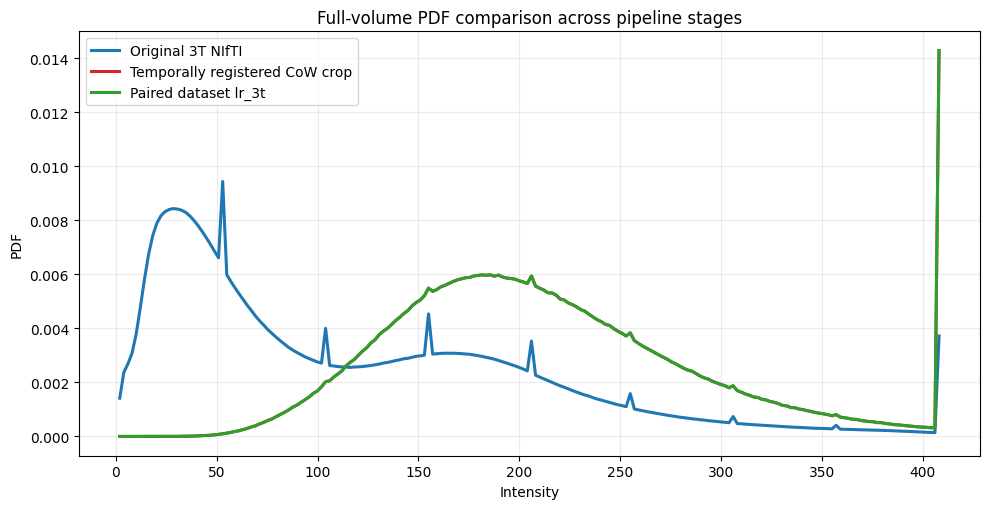

In [28]:
full_volume_map = {
    label: extract_region_values(entry['data'], region='full', time_mode=TIME_MODE, frame_index=FRAME_INDEX)
    for label, entry in loaded.items()
}

full_overlay = prepare_overlay(full_volume_map, bins=HIST_BINS, clip_percentiles=PLOT_CLIP_PERCENTILES)

full_rows = []
for label, overlay in full_overlay.items():
    stats = summarize_values(overlay['raw'])
    full_rows.append({'dataset': label, 'region': 'full', **stats})
full_summary_df = build_summary_table(full_rows)
display(full_summary_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5.2))
for label, overlay in full_overlay.items():
    ax.plot(
        overlay['centers'],
        overlay['pdf'],
        label=label,
        linewidth=2.2,
        color=loaded[label]['style']['color'],
    )
ax.set_title('Full-volume PDF comparison across pipeline stages')
ax.set_xlabel('Intensity')
ax.set_ylabel('PDF')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


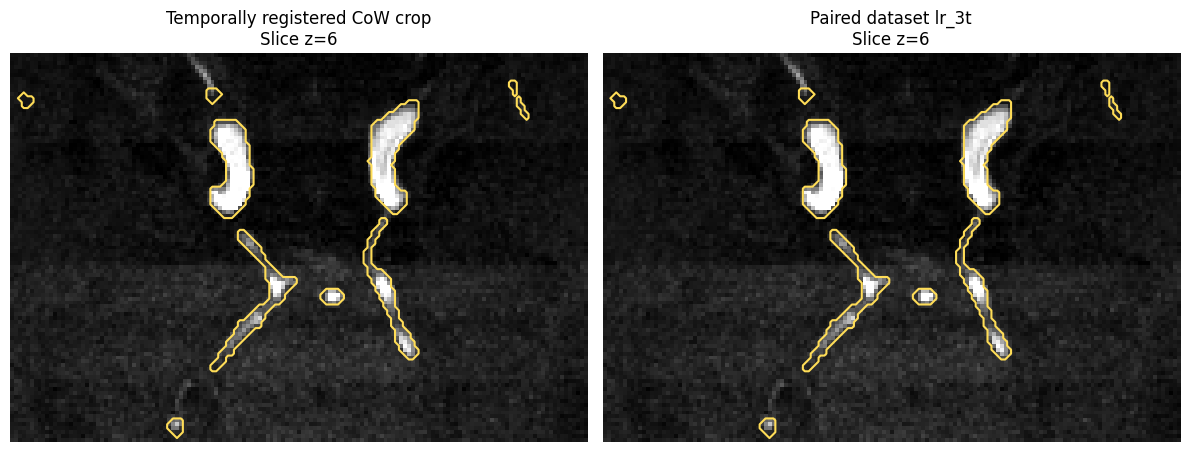

In [29]:
masked_labels = ['Temporally registered CoW crop', 'Paired dataset lr_3t']

fig, axes = plt.subplots(1, len(masked_labels), figsize=(12, 4.8))
if len(masked_labels) == 1:
    axes = [axes]

for ax, label in zip(axes, masked_labels):
    entry = loaded[label]
    volume_3d = representative_volume(entry['data'], frame_index=FRAME_INDEX)
    show_mask_overlay(ax, volume_3d, entry['mask'], title=label)

plt.tight_layout()
plt.show()


In [30]:
region_names = ['full', 'inside_mask', 'outside_mask']
region_title_map = {
    'full': 'Full volume',
    'inside_mask': 'Inside CoW mask',
    'outside_mask': 'Outside CoW mask',
}

region_values = {}
region_rows = []
for label in masked_labels:
    entry = loaded[label]
    region_values[label] = {}
    for region in region_names:
        values = extract_region_values(
            entry['data'],
            mask_3d=entry['mask'],
            region=region,
            time_mode=TIME_MODE,
            frame_index=FRAME_INDEX,
        )
        cleaned = clean_values(values, exclude_zeros=EXCLUDE_ZERO_VALUES, zero_eps=ZERO_EPS)
        region_values[label][region] = cleaned
        region_rows.append({
            'dataset': label,
            'region': region_title_map[region],
            **summarize_values(cleaned),
        })

region_summary_df = build_summary_table(region_rows)
display(region_summary_df.round(4))


,dataset,region,n,mean,std,median,p01,p05,p95,p99,min,max
0,Temporally registered CoW crop,Full volume,6286896,219.2677,111.3833,201.9844,79.3611,107.9982,362.2128,626.5873,19.9977,2592.7759
1,Temporally registered CoW crop,Inside CoW mask,140193,633.9581,379.4130,553.3851,109.9343,166.4757,1347.0958,1683.0826,37.2977,2592.7759
2,Temporally registered CoW crop,Outside CoW mask,6146703,209.8095,73.4455,200.3431,79.1006,107.6151,343.5451,427.6101,19.9977,1308.2026
3,Paired dataset lr_3t,Full volume,6286896,219.2677,111.3833,201.9844,79.3611,107.9982,362.2128,626.5873,19.9977,2592.7759
4,Paired dataset lr_3t,Inside CoW mask,140193,633.9581,379.4130,553.3851,109.9343,166.4757,1347.0958,1683.0826,37.2977,2592.7759
5,Paired dataset lr_3t,Outside CoW mask,6146703,209.8095,73.4455,200.3431,79.1006,107.6151,343.5451,427.6101,19.9977,1308.2026


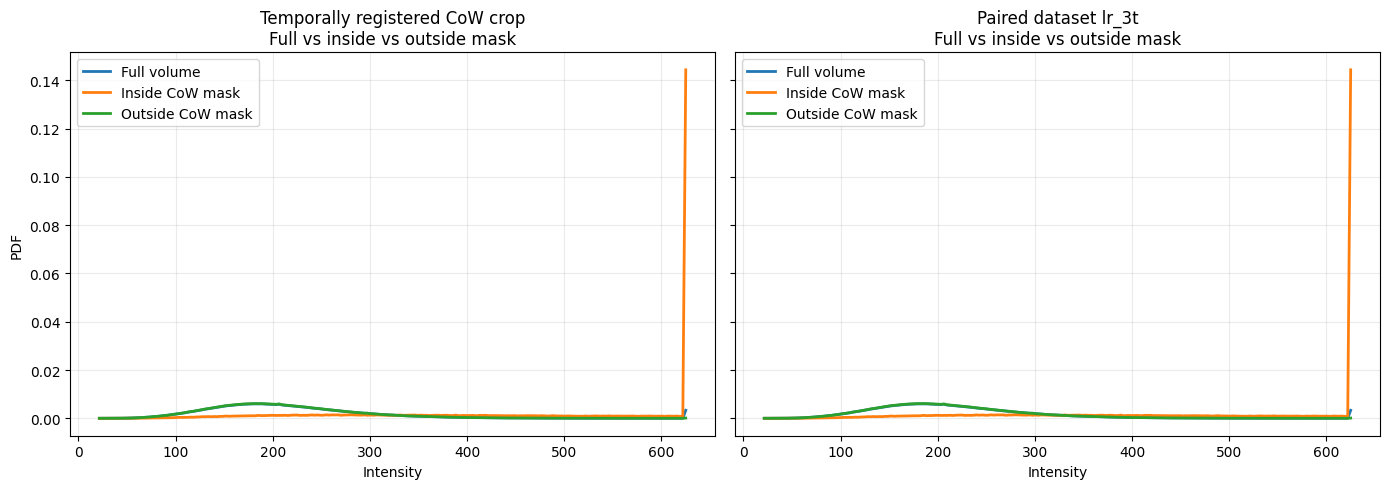

In [31]:
fig, axes = plt.subplots(1, len(masked_labels), figsize=(14, 5.0), sharey=True)
if len(masked_labels) == 1:
    axes = [axes]

region_colors = {
    'full': '#1f77b4',
    'inside_mask': '#ff7f0e',
    'outside_mask': '#2ca02c',
}

for ax, label in zip(axes, masked_labels):
    overlay = prepare_overlay(region_values[label], bins=HIST_BINS, clip_percentiles=PLOT_CLIP_PERCENTILES)
    for region in region_names:
        if region not in overlay:
            warnings.warn(f'Skipping empty region {region} for {label}')
            continue
        ax.plot(
            overlay[region]['centers'],
            overlay[region]['pdf'],
            label=region_title_map[region],
            linewidth=2.0,
            color=region_colors[region],
        )
    ax.set_title(f'{label}\nFull vs inside vs outside mask')
    ax.set_xlabel('Intensity')
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel('PDF')
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, len(region_names), figsize=(16, 4.8), sharey=False)
if len(region_names) == 1:
    axes = [axes]

for ax, region in zip(axes, region_names):
    series_map = {label: region_values[label][region] for label in masked_labels}
    overlay = prepare_overlay(series_map, bins=HIST_BINS, clip_percentiles=PLOT_CLIP_PERCENTILES)
    for label in masked_labels:
        if label not in overlay:
            warnings.warn(f'Skipping empty dataset {label} for region {region}')
            continue
        ax.plot(
            overlay[label]['centers'],
            overlay[label]['pdf'],
            label=label,
            linewidth=2.2,
            color=loaded[label]['style']['color'],
        )
    ax.set_title(region_title_map[region])
    ax.set_xlabel('Intensity')
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel('PDF')
plt.tight_layout()
plt.show()

if EXPORT_SUMMARY_CSV:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    full_summary_df.to_csv(EXPORT_DIR / f'{PATIENT_ID}_full_volume_summary.csv', index=False)
    region_summary_df.to_csv(EXPORT_DIR / f'{PATIENT_ID}_masked_region_summary.csv', index=False)
    print('Saved summary CSV files to', EXPORT_DIR.resolve())


## Next steps
- If you want a single cardiac frame instead of all frames, set `TIME_MODE = "frame"` and choose `FRAME_INDEX`.
- If you want to force a specific original image, set `ORIGINAL_IMAGE_PATH` directly.
- If the outside-mask region is dominated by zero background, keep `EXCLUDE_ZERO_VALUES = True` or tighten `PLOT_CLIP_PERCENTILES`.
